# 03 · Interpretabilidad SHAP · Renfe Price Optimizer

Este notebook explica el modelo final **XGBoost de regresión tabular supervisada** del Renfe Price Optimizer.

**Alcance**
- Modelo cargado desde `models/renfe_model.pkl`.
- Datos explicados: muestra ligera `data/raw/renfe_clean_sample.csv`.

**Objetivos**
1. Calcular importancia global con valores SHAP.
2. Generar gráficos *bar* y *beeswarm*.
3. Analizar el efecto de las variables más relevantes.
4. Explicar predicciones locales mediante *waterfall plots*.
5. Comparar explicaciones por destino.

> El notebook trabaja con una muestra para mantener tiempos y memoria razonables. No carga el CSV completo de 7 GB.

In [8]:
import sys

print(sys.executable)

c:\Users\ES48730183Z\OneDrive - Enel Spa\Escritorio\instlacion\TFM\renfe-price-optimizer\.venv\Scripts\python.exe


In [9]:
import sys

print("Python real del notebook:")
print(sys.executable)

Python real del notebook:
c:\Users\ES48730183Z\OneDrive - Enel Spa\Escritorio\instlacion\TFM\renfe-price-optimizer\.venv\Scripts\python.exe


In [10]:
import shap

print("SHAP:", shap.__version__)

SHAP: 0.52.0


In [11]:
import sys
import shap
import ipykernel

print("Python:", sys.executable)
print("SHAP:", shap.__version__)
print("ipykernel:", ipykernel.__version__)

Python: c:\Users\ES48730183Z\OneDrive - Enel Spa\Escritorio\instlacion\TFM\renfe-price-optimizer\.venv\Scripts\python.exe
SHAP: 0.52.0
ipykernel: 7.3.0


## 1. Preparación

Ejecuta el notebook desde la raíz interna del proyecto. Si falta SHAP, instala la dependencia antes de continuar:

```powershell
uv add shap matplotlib
```

In [12]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap


PROJECT_ROOT = Path(
    r"C:\Users\ES48730183Z\OneDrive - Enel Spa\Escritorio\instlacion\TFM"
    r"\renfe-price-optimizer\renfe-price-optimizer"
)

SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

ROOT = PROJECT_ROOT
MODEL_PATH = ROOT / "models" / "renfe_model.pkl"
SAMPLE_PATH = ROOT / "data" / "raw" / "renfe_clean_sample.csv"
REPORTS_DIR = ROOT / "reports" / "shap"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")

print("Python:", sys.executable)
print("SHAP:", shap.__version__)
print("Proyecto:", PROJECT_ROOT)
print("src:", SRC_PATH)
print("Modelo:", MODEL_PATH)
print("Sample:", SAMPLE_PATH)
print("Salida:", REPORTS_DIR)

Python: c:\Users\ES48730183Z\OneDrive - Enel Spa\Escritorio\instlacion\TFM\renfe-price-optimizer\.venv\Scripts\python.exe
SHAP: 0.52.0
Proyecto: C:\Users\ES48730183Z\OneDrive - Enel Spa\Escritorio\instlacion\TFM\renfe-price-optimizer\renfe-price-optimizer
src: C:\Users\ES48730183Z\OneDrive - Enel Spa\Escritorio\instlacion\TFM\renfe-price-optimizer\renfe-price-optimizer\src
Modelo: C:\Users\ES48730183Z\OneDrive - Enel Spa\Escritorio\instlacion\TFM\renfe-price-optimizer\renfe-price-optimizer\models\renfe_model.pkl
Sample: C:\Users\ES48730183Z\OneDrive - Enel Spa\Escritorio\instlacion\TFM\renfe-price-optimizer\renfe-price-optimizer\data\raw\renfe_clean_sample.csv
Salida: C:\Users\ES48730183Z\OneDrive - Enel Spa\Escritorio\instlacion\TFM\renfe-price-optimizer\renfe-price-optimizer\reports\shap


## 2. Carga del modelo y de la muestra

El modelo guardado es un `Pipeline` de scikit-learn. El notebook localiza automáticamente el preprocesador y el estimador XGBoost para poder explicar el espacio transformado que consume el modelo.

In [13]:
assert MODEL_PATH.exists(), f"No se encuentra el modelo: {MODEL_PATH}"
assert SAMPLE_PATH.exists(), f"No se encuentra el sample: {SAMPLE_PATH}"

pipeline = joblib.load(MODEL_PATH)
df_raw = pd.read_csv(SAMPLE_PATH)

print("Tipo de artefacto:", type(pipeline).__name__)
print("Filas del sample:", len(df_raw))
print("Columnas:", list(df_raw.columns))

Tipo de artefacto: Pipeline
Filas del sample: 10000
Columnas: ['ciudad_origen', 'ciudad_destino', 'fecha_salida', 'fecha_llegada', 'duracion', 'tipo_tren', 'clase', 'precio', 'tarifa', 'fecha_captura', 'mes_salida', 'dia_semana', 'hora_salida', 'hora_captura', 'dias_anticipacion', 'temporada', 'duracion_minutos']


## 3. Transformación al esquema del modelo

Se reutiliza `build_features()` para garantizar que SHAP explica exactamente las mismas variables que consume el entrenamiento.

In [14]:
from renfe_optimizer.features import build_features

TARGET = "price"
MAX_EXPLAIN_ROWS = 2_000
RANDOM_STATE = 42

model_df = build_features(df_raw)
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

if len(X) > MAX_EXPLAIN_ROWS:
    X_explain = X.sample(MAX_EXPLAIN_ROWS, random_state=RANDOM_STATE)
    y_explain = y.loc[X_explain.index]
else:
    X_explain = X.copy()
    y_explain = y.copy()

print("Esquema del modelo:", list(X.columns))
print("Filas usadas por SHAP:", len(X_explain))
print("Destinos:", sorted(X_explain["destino"].unique()))

Esquema del modelo: ['origen', 'destino', 'vehicle_type', 'vehicle_class', 'fare', 'duration', 'dias_anticipacion', 'hora_salida', 'dia_semana', 'mes', 'temporada']
Filas usadas por SHAP: 2000
Destinos: ['BARCELONA', 'MADRID', 'MÁLAGA', 'SEVILLA', 'VALENCIA']


## 4. Identificación del preprocesador y del XGBoost

La búsqueda es deliberadamente flexible para no depender de nombres exactos como `preprocessor`, `regressor`, `model` o `estimator`.

In [15]:
def localizar_componentes(pipe):
    if not hasattr(pipe, "named_steps"):
        raise TypeError("El artefacto no es un Pipeline con named_steps.")

    preprocessor = None
    estimator = None

    for _, step in pipe.named_steps.items():
        nombre = step.__class__.__name__.lower()
        if hasattr(step, "get_feature_names_out") and hasattr(step, "transform"):
            preprocessor = step
        if "xgb" in nombre or "xgboost" in nombre:
            estimator = step

    if estimator is None:
        estimator = list(pipe.named_steps.values())[-1]

    if preprocessor is None:
        candidates = list(pipe.named_steps.values())[:-1]
        if candidates:
            preprocessor = candidates[-1]

    return preprocessor, estimator

preprocessor, xgb_model = localizar_componentes(pipeline)
print("Preprocesador:", type(preprocessor).__name__)
print("Estimador:", type(xgb_model).__name__)

Preprocesador: ColumnTransformer
Estimador: XGBRegressor


## 5. Matriz transformada y nombres de variables

Las categorías se codifican antes de llegar a XGBoost. Los nombres transformados permiten interpretar, por ejemplo, `destino_BARCELONA` o `fare_Promo` en los gráficos SHAP.

In [16]:
X_transformed = preprocessor.transform(X_explain)

if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

try:
    feature_names = list(preprocessor.get_feature_names_out())
except Exception:
    feature_names = [f"feature_{i}" for i in range(X_transformed.shape[1])]

X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names,
    index=X_explain.index,
)

print("Shape transformado:", X_transformed_df.shape)
print("Primeras variables:", feature_names[:15])

Shape transformado: (2000, 48)
Primeras variables: ['num__duration', 'num__dias_anticipacion', 'num__hora_salida', 'num__mes', 'cat__origen_BARCELONA', 'cat__origen_MADRID', 'cat__origen_MÁLAGA', 'cat__origen_SEVILLA', 'cat__origen_VALENCIA', 'cat__destino_BARCELONA', 'cat__destino_MADRID', 'cat__destino_MÁLAGA', 'cat__destino_SEVILLA', 'cat__destino_VALENCIA', 'cat__vehicle_type_ALVIA']


## 6. Cálculo de valores SHAP

`TreeExplainer` está optimizado para modelos basados en árboles como XGBoost. Los valores SHAP indican cuánto empuja cada variable la predicción por encima o por debajo del valor base.

In [17]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_transformed_df)

print("Shape de los valores SHAP:", shap_values.values.shape)
print("Valor base medio:", float(np.mean(shap_values.base_values)))

Shape de los valores SHAP: (2000, 48)
Valor base medio: 63.27201843261719


## 7. Importancia global

La importancia global se calcula como el valor absoluto medio de SHAP por variable. Una magnitud alta indica que la variable modifica con frecuencia la predicción, pero no implica causalidad.

In [18]:
importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

importance.head(20)

,feature,mean_abs_shap
32,cat__fare_Flexible,9.193189
0,num__duration,6.114946
17,cat__vehicle_type_AVE,5.770593
9,cat__destino_BARCELONA,3.455786
4,cat__origen_BARCELONA,3.032806
27,cat__vehicle_class_Turista,2.636443
2,num__hora_salida,1.969247
1,num__dias_anticipacion,1.712648
7,cat__origen_SEVILLA,1.497590
12,cat__destino_SEVILLA,1.145317


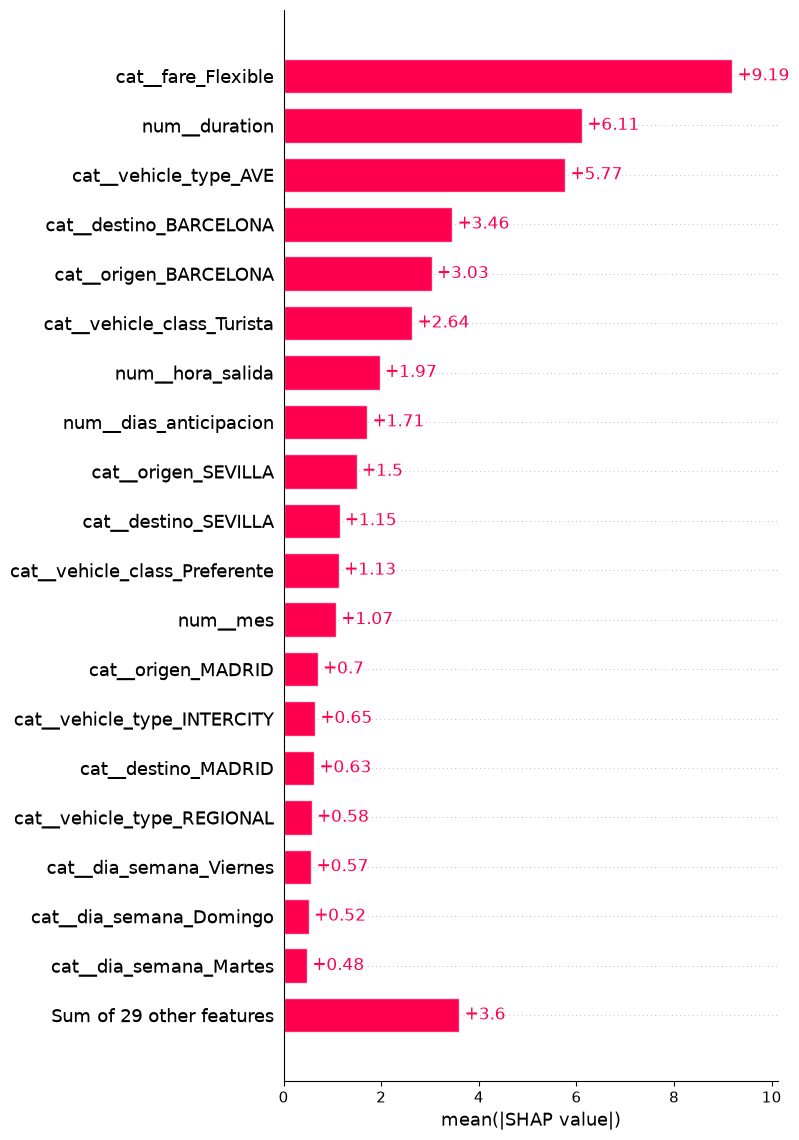

In [19]:
importance.to_csv(REPORTS_DIR / "shap_importance.csv", index=False)

plt.figure(figsize=(10, 7))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "shap_global_bar.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Beeswarm global

El gráfico muestra simultáneamente magnitud y dirección del efecto. Los puntos a la derecha elevan la predicción; los puntos a la izquierda la reducen.

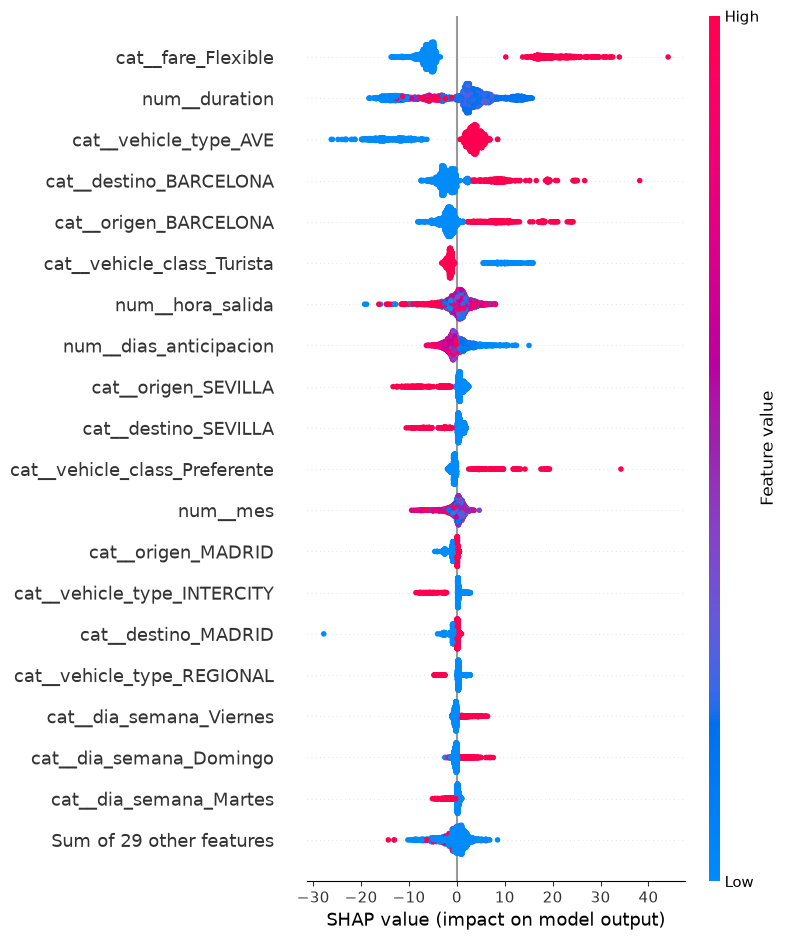

In [20]:
plt.figure(figsize=(11, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "shap_beeswarm.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Dependencia de las variables más relevantes

Se generan gráficos de dispersión para las cinco variables con mayor importancia global. Estos gráficos ayudan a observar relaciones no lineales y posibles interacciones.

<Figure size 900x500 with 0 Axes>

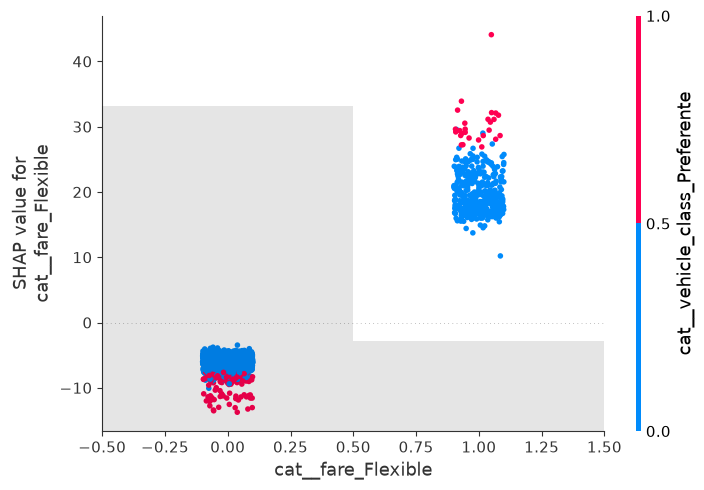

<Figure size 900x500 with 0 Axes>

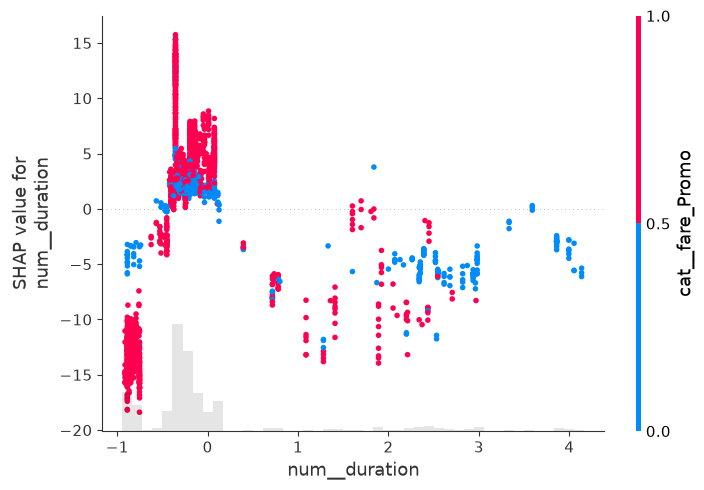

<Figure size 900x500 with 0 Axes>

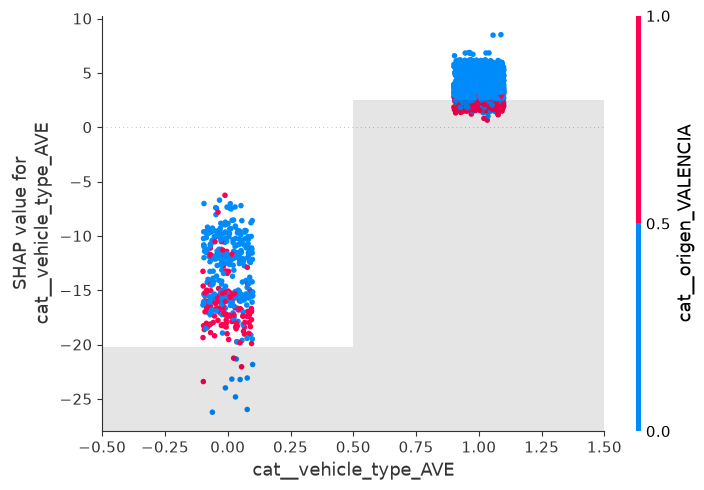

<Figure size 900x500 with 0 Axes>

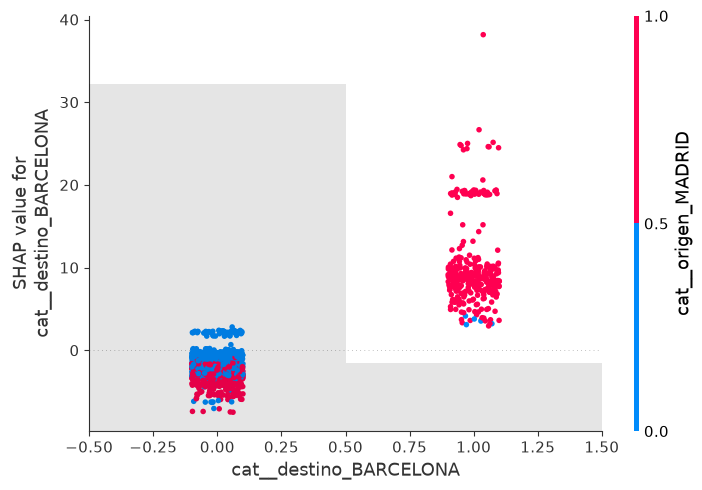

<Figure size 900x500 with 0 Axes>

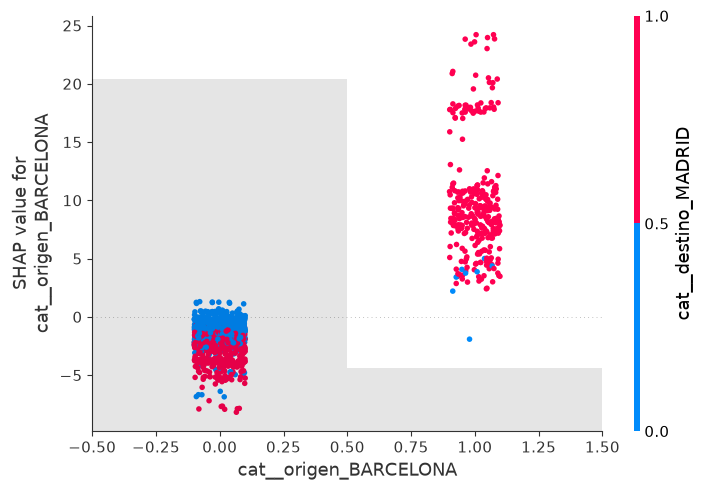

In [21]:
TOP_DEPENDENCE = 5

top_features = importance.head(TOP_DEPENDENCE)["feature"].tolist()
for feature in top_features:
    idx = feature_names.index(feature)
    plt.figure(figsize=(9, 5))
    shap.plots.scatter(shap_values[:, idx], color=shap_values, show=False)
    safe_name = feature.replace("/", "_").replace(" ", "_")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"dependence_{safe_name}.png", dpi=180, bbox_inches="tight")
    plt.show()

## 10. Explicaciones locales

Los *waterfall plots* explican predicciones individuales. Se selecciona un caso de cada destino presente en la muestra.

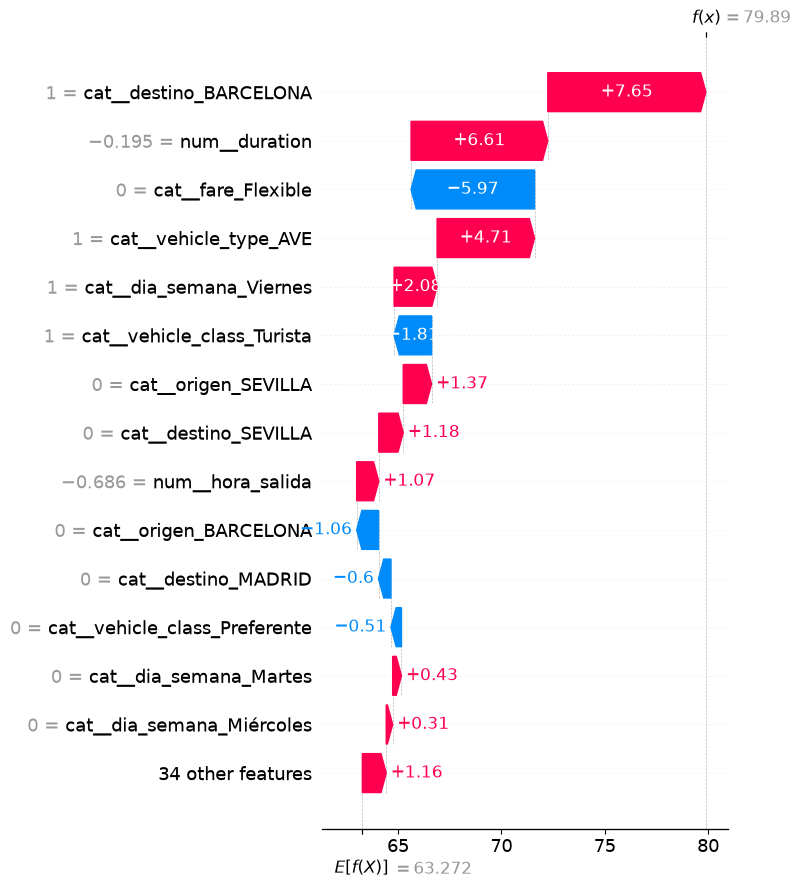

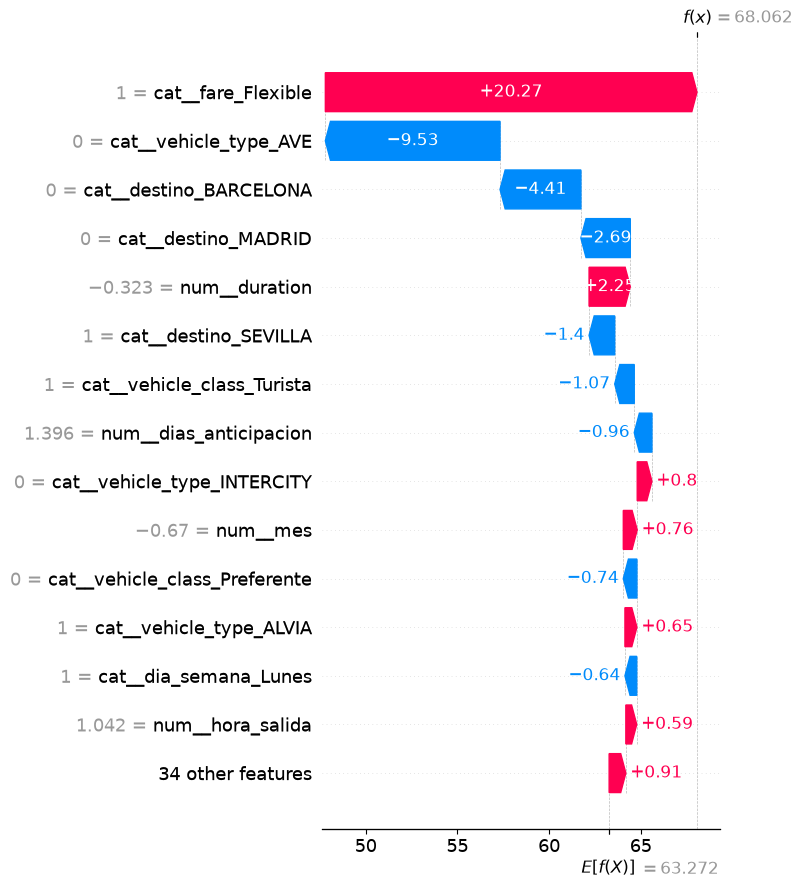

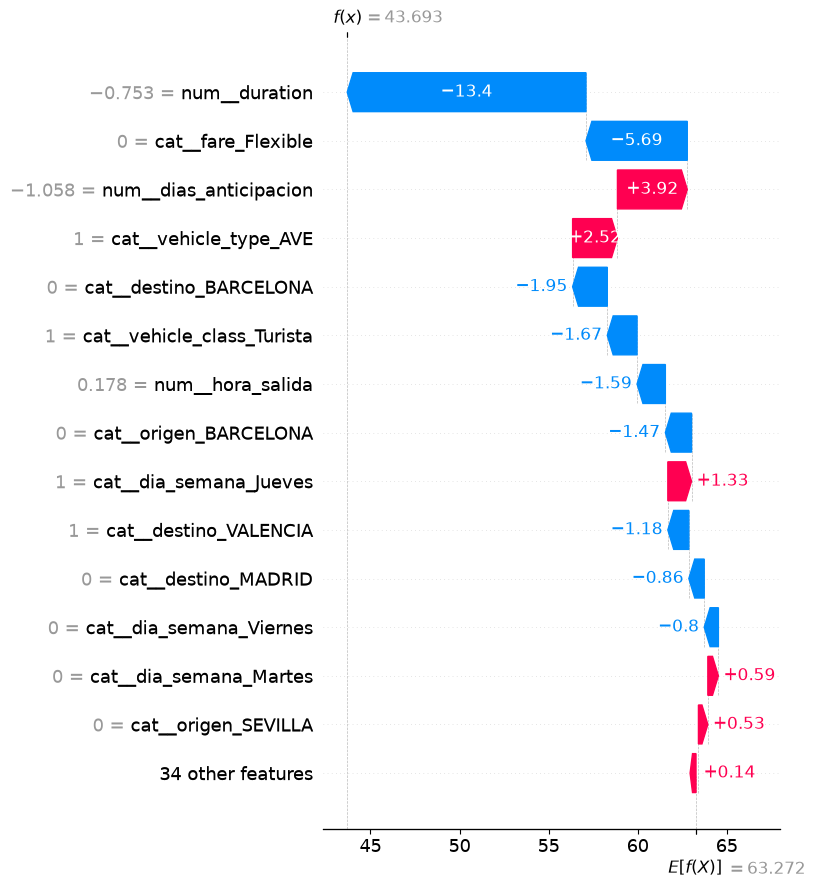

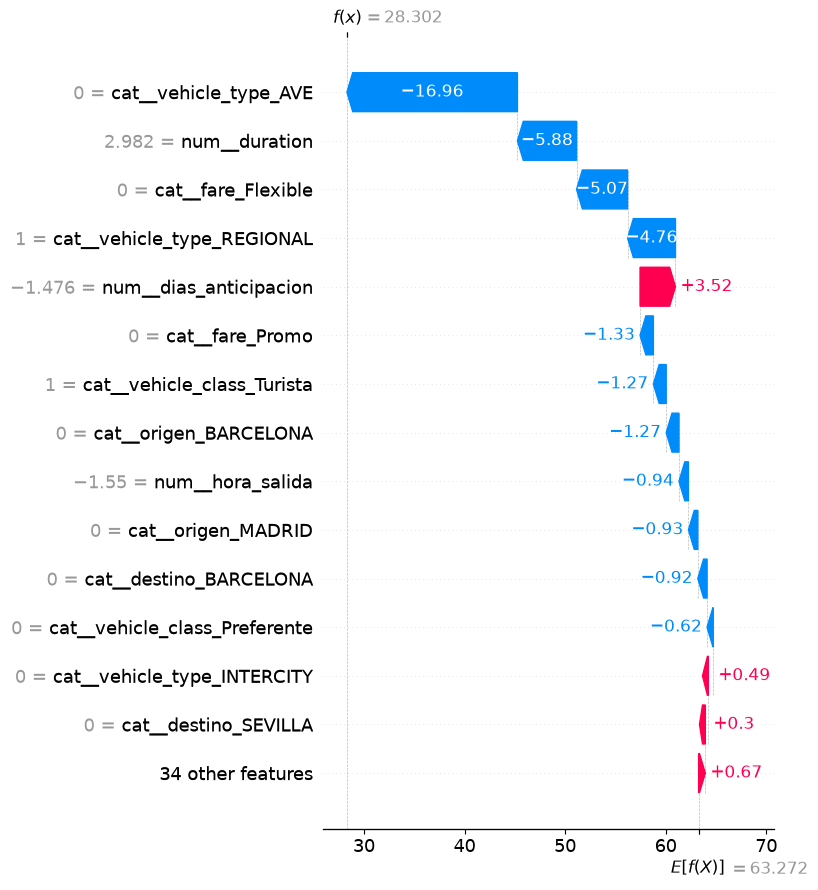

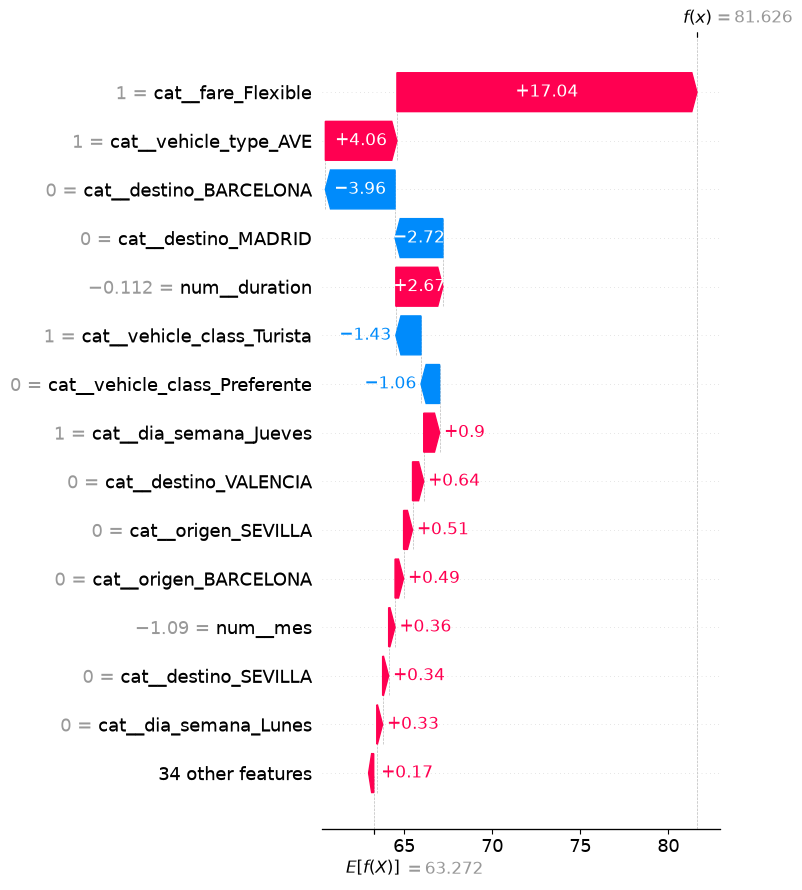

,destino,precio_real,precio_predicho,error_absoluto
0,BARCELONA,76.25,79.890060,3.640060
1,SEVILLA,67.90,68.062462,0.162462
2,VALENCIA,45.80,43.693142,2.106858
3,MADRID,28.35,28.301720,0.048280
4,MÁLAGA,81.20,81.626373,0.426373


In [22]:
local_cases = []
for destino in ["BARCELONA", "SEVILLA", "VALENCIA", "MADRID", "MÁLAGA"]:
    matches = X_explain.index[X_explain["destino"] == destino].tolist()
    if matches:
        original_index = matches[0]
        pos = X_explain.index.get_loc(original_index)
        local_cases.append((destino, original_index, pos))

local_summary = []
for destino, original_index, pos in local_cases:
    prediction = float(pipeline.predict(X_explain.loc[[original_index]])[0])
    actual = float(y_explain.loc[original_index])
    local_summary.append({
        "destino": destino,
        "precio_real": actual,
        "precio_predicho": prediction,
        "error_absoluto": abs(actual - prediction),
    })

    plt.figure(figsize=(10, 7))
    shap.plots.waterfall(shap_values[pos], max_display=15, show=False)
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"waterfall_{destino.lower()}.png", dpi=180, bbox_inches="tight")
    plt.show()

pd.DataFrame(local_summary)

## 11. Importancia agregada por variable original

El *one-hot encoding* genera varias columnas por variable categórica. Este bloque agrega todas las categorías bajo su variable original para obtener una lectura de negocio más clara.

In [23]:
ORIGINAL_FEATURES = [
    "origen",
    "destino",
    "vehicle_type",
    "vehicle_class",
    "fare",
    "duration",
    "dias_anticipacion",
    "hora_salida",
    "dia_semana",
    "mes",
    "temporada",
]

def original_feature_name(transformed_name: str) -> str:
    clean = transformed_name.split("__", 1)[-1]
    for feature in sorted(ORIGINAL_FEATURES, key=len, reverse=True):
        if clean == feature or clean.startswith(f"{feature}_"):
            return feature
    return clean

importance["original_feature"] = importance["feature"].map(original_feature_name)
importance_grouped = (
    importance.groupby("original_feature", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
)

importance_grouped.to_csv(REPORTS_DIR / "shap_importance_grouped.csv", index=False)
importance_grouped

,original_feature,mean_abs_shap
4,fare,9.556567
10,vehicle_type,7.408988
3,duration,6.114946
0,destino,5.931903
7,origen,5.709151
9,vehicle_class,3.838991
1,dia_semana,2.760813
5,hora_salida,1.969247
2,dias_anticipacion,1.712648
6,mes,1.073815


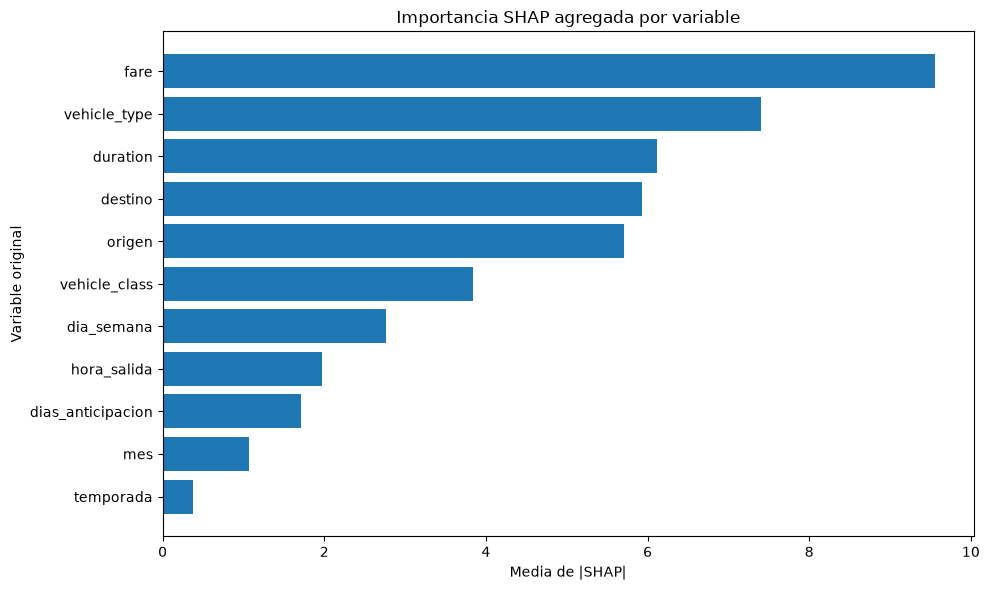

In [24]:
plt.figure(figsize=(10, 6))
plot_df = importance_grouped.sort_values("mean_abs_shap")
plt.barh(plot_df["original_feature"], plot_df["mean_abs_shap"])
plt.xlabel("Media de |SHAP|")
plt.ylabel("Variable original")
plt.title("Importancia SHAP agregada por variable")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "shap_importance_grouped.png", dpi=180, bbox_inches="tight")
plt.show()

## 12. Resumen automático para la memoria

El texto siguiente se genera a partir de los resultados reales obtenidos. Debe interpretarse como asociación predictiva, no como causalidad.

In [25]:
top_grouped = importance_grouped.head(5)["original_feature"].tolist()

summary = {
    "modelo": type(xgb_model).__name__,
    "filas_explicadas": int(len(X_explain)),
    "variables_mas_relevantes": top_grouped,
    "destinos_analizados": sorted(X_explain["destino"].unique().tolist()),
    "nota": "Las importancias SHAP describen contribuciones al modelo, no relaciones causales.",
}

with open(REPORTS_DIR / "shap_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "modelo": "XGBRegressor",
  "filas_explicadas": 2000,
  "variables_mas_relevantes": [
    "fare",
    "vehicle_type",
    "duration",
    "destino",
    "origen"
  ],
  "destinos_analizados": [
    "BARCELONA",
    "MADRID",
    "MÁLAGA",
    "SEVILLA",
    "VALENCIA"
  ],
  "nota": "Las importancias SHAP describen contribuciones al modelo, no relaciones causales."
}


## 13. Interpretabilidad del modelo mediante SHAP

### 13.1. Objetivo del análisis

Para interpretar el comportamiento del modelo final XGBoost se aplicó SHAP
sobre una muestra representativa de 2.000 observaciones del dataset limpio, que
recoge **corredores bidireccionales entre Madrid, Barcelona, Sevilla, Valencia
y Málaga**. Cada una de estas ciudades puede actuar tanto como origen como
destino del trayecto.

El análisis permite conocer:

1. Qué variables tienen mayor influencia global sobre las predicciones.
2. Qué valores o categorías contribuyen a elevar o reducir el precio estimado.
3. Cómo interactúan las variables más importantes.
4. Qué factores explican predicciones individuales para los distintos corredores.

El modelo recibe variables numéricas y categóricas. Las variables categóricas
se transforman mediante one-hot encoding, por lo que en los gráficos aparecen
columnas como:

- `cat__origen_MADRID`
- `cat__origen_MÁLAGA`
- `cat__destino_BARCELONA`
- `cat__fare_Flexible`
- `cat__vehicle_type_AVE`
- `cat__vehicle_class_Turista`

En estas variables:

- Un valor igual a `1` indica que la observación pertenece a esa categoría.
- Un valor igual a `0` indica que no pertenece a esa categoría.

En las variables numéricas pueden aparecer valores estandarizados, por lo que
valores como `-1,37` o `0,98` no representan directamente días, horas o duración
en unidades originales.

Un valor SHAP positivo contribuye a elevar la predicción respecto al valor base,
mientras que un valor SHAP negativo contribuye a reducirla.

Los valores SHAP explican cómo utiliza el modelo las variables, pero no demuestran
relaciones causales.

---

### 13.2. Importancia global agregada

La importancia global se calculó mediante la media del valor absoluto de SHAP
para cada variable. Posteriormente, las columnas generadas por el one-hot encoding
se agregaron por variable original.

| Posición | Variable | Media de \|SHAP\| |
|---:|---|---:|
| 1 | Tarifa (`fare`) | 9,56 |
| 2 | Tipo de tren (`vehicle_type`) | 7,41 |
| 3 | Duración (`duration`) | 6,11 |
| 4 | Destino (`destino`) | 5,93 |
| 5 | Origen (`origen`) | 5,71 |
| 6 | Clase (`vehicle_class`) | 3,84 |
| 7 | Día de la semana (`dia_semana`) | 2,76 |
| 8 | Hora de salida (`hora_salida`) | 1,97 |
| 9 | Días de antelación (`dias_anticipacion`) | 1,71 |
| 10 | Mes (`mes`) | 1,07 |
| 11 | Temporada (`temporada`) | 0,37 |

La tarifa es la variable con mayor influencia global, seguida del tipo de tren y
la duración. A continuación se sitúan, de forma muy próxima entre sí, el destino
(5,93) y el origen (5,71). El hecho de que **origen y destino presenten una
importancia prácticamente equivalente** confirma que ambas ciudades del trayecto
son determinantes para el precio y que el modelo diferencia claramente los
corredores en ambos sentidos.

La clase también presenta una contribución considerable. Las variables temporales
tienen una importancia global inferior, aunque algunas continúan siendo relevantes
para casos concretos y para la lógica operativa de la aplicación.

---

### 13.3. Interpretación de la tarifa

La tarifa es la variable con mayor importancia global, con una media absoluta
SHAP de 9,56.

La categoría `fare_Flexible` muestra una separación especialmente clara:

- Cuando la tarifa es Flexible, las observaciones aparecen mayoritariamente con
  valores SHAP positivos.
- La tarifa Flexible está, por tanto, asociada a predicciones superiores al valor
  base.
- Cuando la tarifa no es Flexible, la contribución tiende a ser negativa o cercana
  a cero.

Estos resultados muestran que el modelo utiliza la flexibilidad tarifaria como
uno de los principales elementos para separar servicios de mayor y menor precio.

No debe interpretarse que la tarifa Flexible cause por sí sola el incremento.
La contribución final depende también del origen, el destino, el tipo de tren,
la clase, la duración y las variables temporales.

---

### 13.4. Interpretación del tipo de tren

El tipo de tren ocupa la segunda posición, con una importancia global de 7,41.

La categoría `vehicle_type_AVE` presenta uno de los patrones más claros del
análisis:

- Cuando la observación corresponde a un AVE, la contribución tiende a ser
  positiva.
- Cuando la observación no corresponde a un AVE, la contribución de esta variable
  puede ser fuertemente negativa.
- El modelo distingue de forma clara los servicios AVE de otros servicios como
  ALVIA, INTERCITY, AV City, Regional, MD o Regional Exprés.

El modelo identifica, por tanto, una diferenciación relevante entre los distintos
servicios ferroviarios.

---

### 13.5. Interpretación de la duración

La duración presenta una importancia global de 6,11.

Los gráficos de dependencia muestran un comportamiento claramente no lineal:

- Algunas duraciones normalizadas se asocian a contribuciones negativas elevadas.
- Otras duraciones intermedias producen contribuciones positivas.
- Determinadas duraciones altas presentan contribuciones ligeramente negativas.
- No existe una relación lineal simple de tipo "a mayor duración, mayor precio".

Este comportamiento es coherente con la interacción entre duración, corredor y
tipo de servicio. Una duración determinada puede corresponder a un servicio de
alta velocidad, a un tren regional o a un servicio intermedio. Por tanto, la
duración debe interpretarse conjuntamente con el origen, el destino y el tipo de
tren.

---

### 13.6. Interpretación del destino

El destino es la cuarta variable más relevante, con una importancia global de
5,93.

Las categorías de destino muestran contribuciones diferenciadas según el corredor:

- Determinados destinos aparecen frecuentemente asociados a valores SHAP positivos.
- En el gráfico de dependencia, las observaciones se separan según la ciudad de
  llegada.
- Cuando el destino no coincide con la categoría analizada, su contribución es
  generalmente negativa o cercana a cero.

La elevada importancia del destino confirma que era necesario modelar
explícitamente los distintos corredores. El modelo reconoce diferencias
estructurales entre los trayectos analizados y no trata todos los destinos como
si tuvieran el mismo comportamiento tarifario.

---

### 13.7. Interpretación del origen

El origen es la quinta variable más relevante, con una importancia global de
5,71, prácticamente equivalente a la del destino.

Esta variable **no formaba parte de la versión inicial del modelo**, que asumía
Madrid como origen único. Al confirmarse que el dataset contiene trayectos
bidireccionales, se incorporó `ciudad_origen` como variable, y el análisis SHAP
demuestra que su aportación es de primer orden:

- Las distintas categorías de origen (`origen_MADRID`, `origen_MÁLAGA`,
  `origen_BARCELONA`, `origen_SEVILLA`, `origen_VALENCIA`) presentan
  contribuciones diferenciadas.
- El modelo distingue el nivel de precio según la ciudad de salida, y no solo
  según la de llegada.
- La similitud entre la importancia de origen y destino es coherente con un
  sistema de corredores simétricos, en el que el precio depende del par
  origen-destino completo.

Este resultado valida empíricamente la decisión de ampliar el modelo: el origen
aportaba información relevante que la versión anterior estaba ignorando, lo que
explica la mejora de las métricas tras el reentrenamiento (véase 13.13).

---

### 13.8. Interpretación de la clase

La clase presenta una importancia global de 3,84.

La categoría `vehicle_class_Turista` muestra principalmente contribuciones
negativas cuando está activa:

- La clase Turista está asociada a predicciones inferiores al valor base.
- Cuando la observación no pertenece a Turista, la contribución puede ser
  positiva.

La categoría Preferente aparece asociada a contribuciones positivas en distintas
observaciones del análisis global.

El modelo refleja así la diferenciación comercial entre clases:

- Turista se relaciona generalmente con precios inferiores.
- Preferente se relaciona generalmente con precios superiores.
- Turista Plus ocupa una posición intermedia cuya contribución depende del resto
  de variables.

De nuevo, se trata de asociaciones aprendidas por el modelo y no de una
estimación causal aislada del efecto de cambiar de clase.

---

### 13.9. Día de la semana y hora de salida

El día de la semana alcanza una importancia global de 2,76 y la hora de salida
una importancia de 1,97.

Estas variables tienen una influencia moderada frente a tarifa, tipo de tren,
duración, destino y origen.

En el beeswarm se observan categorías concretas, como el viernes, asociadas a
contribuciones positivas en determinadas observaciones. Sin embargo, la magnitud
es menor que la de las principales variables comerciales y de corredor.

La hora de salida presenta efectos en ambas direcciones y no actúa de forma
aislada: el efecto depende del corredor, el tipo de tren, la tarifa y el resto de
condiciones del trayecto.

---

### 13.10. Días de antelación

Los días de antelación presentan una importancia global de 1,71.

Este valor es inferior al de las principales variables comerciales, pero no
significa que la antelación sea irrelevante para la aplicación.

Los valores mostrados en los gráficos están estandarizados, por lo que no deben
interpretarse directamente como días naturales.

La importancia SHAP global mide cuánto contribuye una variable a explicar las
predicciones del conjunto. La aplicación, en cambio, utiliza `dias_anticipacion`
de manera operativa y deliberada:

1. Mantiene constantes las características del billete.
2. Modifica los días de antelación.
3. Estima el precio para distintas ventanas futuras.
4. Construye la curva precio-antelación.
5. Decide entre comprar ahora o esperar.

Por tanto, una variable puede tener una importancia global moderada y al mismo
tiempo ser esencial para la funcionalidad de recomendación.

---

### 13.11. Mes y temporada

El mes presenta una importancia global de 1,07 y la temporada una importancia de
0,37.

Son las variables con menor contribución global de las analizadas.

Esto puede estar relacionado con la limitada cobertura temporal de los datos, que
concentran observaciones en un conjunto reducido de meses y temporadas. La escasa
variabilidad temporal limita la capacidad del modelo para aprender diferencias
estacionales amplias.

No debe concluirse que la estacionalidad carezca de relevancia en otros periodos.
El resultado únicamente indica que, dentro del dataset y la muestra analizados,
el modelo utiliza menos estas variables que la tarifa, el servicio, la duración
o el corredor (origen y destino).

---

### 13.12. Interpretaciones locales mediante waterfall plots

Los waterfall plots permiten explicar predicciones individuales respecto al valor
base del modelo. Se generó un caso representativo para cada ciudad como destino:
Barcelona, Sevilla, Valencia, Málaga y Madrid.

Cada gráfico comienza en el valor base y suma o resta las contribuciones SHAP de
cada variable hasta alcanzar la predicción final `f(x)`.

> **Nota:** las contribuciones concretas (en euros) de cada waterfall deben leerse
> directamente de las figuras regeneradas en `reports/shap/`
> (`waterfall_barcelona.png`, `waterfall_sevilla.png`, `waterfall_valencia.png`,
> `waterfall_málaga.png`, `waterfall_madrid.png`), ya que corresponden al modelo
> reentrenado con la variable origen y no deben reutilizarse cifras de versiones
> anteriores.

Los principales patrones observados de forma consistente son:

- Una tarifa Flexible tiende a elevar considerablemente la predicción.
- La ausencia o presencia de AVE puede modificar el precio de forma notable.
- Tanto el origen como el destino elevan o reducen la predicción según el corredor.
- La clase Turista tiende a reducir la predicción.
- La duración puede tener contribuciones positivas o negativas según el servicio.
- La antelación y la hora de salida ajustan la predicción con menor intensidad,
  pero pueden resultar relevantes en casos individuales.

Estos ejemplos muestran que el precio final no depende de una única variable. El
modelo combina simultáneamente información sobre origen, destino, tarifa, servicio,
clase, duración y temporalidad.

---

### 13.13. Corredores bidireccionales y variable origen

El análisis inicial detectó la categoría `cat__destino_MADRID`, lo que llevó a
verificar el sentido de los trayectos. Se confirmó que **el dataset contiene
corredores bidireccionales**: cada ciudad (Madrid, Barcelona, Sevilla, Valencia y
Málaga) aparece tanto como origen como destino.

En consecuencia, se incorporó **`ciudad_origen` como variable del modelo**, ya que
el origen dejó de ser constante. El alcance correcto del proyecto es:

> Corredores bidireccionales entre Madrid, Barcelona, Sevilla, Valencia y Málaga.

Tras reincorporar el origen y reentrenar el modelo sobre el dataset completo, las
métricas **mejoraron** respecto a la versión anterior:

| Métrica | Antes (sin origen) | Después (con origen y Málaga) |
|---|---:|---:|
| MAE | 4,42 € | 4,07 € |
| RMSE | 6,73 € | 6,17 € |
| MAPE | 8,16 % | 7,67 % |
| R² | 0,931 | 0,942 |

La mejora en todas las métricas, junto con la elevada importancia SHAP del origen
(5,71, quinta posición), confirma que el origen aporta información relevante que
la versión anterior estaba ignorando. El resultado valida la decisión de modelar
el trayecto completo mediante el par origen-destino.

---

### 13.14. Limitaciones de la interpretación

El análisis SHAP presenta varias limitaciones que deben tenerse en cuenta:

1. Los resultados describen el comportamiento del modelo, no necesariamente el
   funcionamiento causal del mercado ferroviario.
2. La importancia global puede ocultar efectos locales relevantes.
3. Las variables categóricas se expanden mediante one-hot encoding y deben
   agregarse para obtener una lectura por variable original.
4. Las variables numéricas transformadas aparecen estandarizadas en algunos
   gráficos.
5. Las interacciones entre variables pueden producir efectos no lineales.
6. El análisis se realiza sobre una muestra de 2.000 observaciones y no sobre los
   más de 13 millones de registros completos.
7. El dataset histórico no recoge necesariamente el comportamiento actual del
   mercado ferroviario.
8. La cobertura limitada de meses y temporadas puede reducir la importancia
   estimada de las variables estacionales.

---

### 13.15. Conclusión general

El análisis SHAP proporciona una explicación consistente del modelo XGBoost.

La tarifa es la variable con mayor influencia global, seguida del tipo de tren, la
duración y, de forma muy próxima entre sí, el destino y el origen. Estas variables
representan las características comerciales, operativas y de corredor más utilizadas
por el modelo para distinguir niveles de precio.

La incorporación del origen como variable —motivada por la naturaleza bidireccional
de los corredores— resultó decisiva: alcanza una importancia prácticamente
equivalente a la del destino y su inclusión mejoró todas las métricas del modelo.
Ello demuestra que el precio depende del par origen-destino completo y no
únicamente de la ciudad de llegada.

La tarifa Flexible, el servicio AVE y la clase Preferente presentan generalmente
contribuciones asociadas a predicciones superiores. La clase Turista se asocia
principalmente a contribuciones negativas. La duración presenta un comportamiento
no lineal y debe interpretarse junto con la ruta y el tipo de servicio. Las
variables temporales tienen una importancia global inferior, aunque continúan
interviniendo en predicciones concretas.

Los días de antelación presentan una importancia global moderada, pero son
esenciales para construir la curva de precios y generar la recomendación de
comprar o esperar.

Finalmente, las explicaciones globales y locales mejoran la trazabilidad del
modelo, permiten justificar sus predicciones y reducen la opacidad del sistema.
Los resultados deben interpretarse como contribuciones predictivas, no como
relaciones causales.
